In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
dataset=pd.read_csv('height-weight.csv')

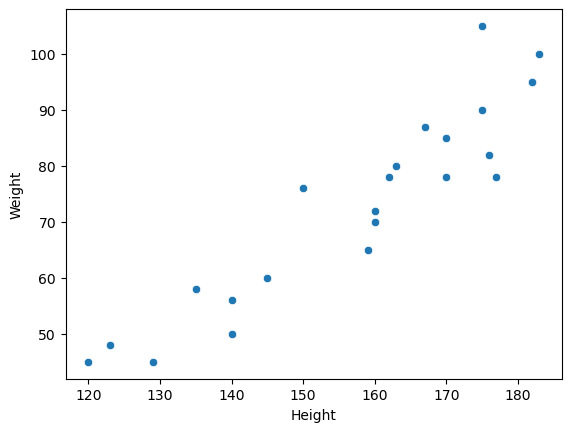

In [5]:
scatter = sns.scatterplot(x='Height',y='Weight',data=dataset)

In [8]:
##divide the dataset into independent and dependent features
X=dataset['Weight']##independent features
y=dataset['Height']##dependent features


In [13]:
from sklearn.model_selection import train_test_split
train_X,test_X,train_y,test_y=train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
X.shape

(23,)

In [15]:
train_X.shape,test_X.shape,train_y.shape,test_y.shape

((18,), (5,), (18,), (5,))

In [16]:
##standarize the dataset
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [17]:
scaler.fit_transform(train_X.values.reshape(-1,1))

array([[ 1.73689094],
       [-0.92026952],
       [ 1.4542143 ],
       [ 0.21043706],
       [-1.48562281],
       [ 1.17153765],
       [-1.6552288 ],
       [-0.80719886],
       [-0.24184557],
       [ 0.0973664 ],
       [-1.37255215],
       [-1.03334018],
       [-0.12877492],
       [ 0.88886101],
       [ 0.43657837],
       [ 0.60618436],
       [ 0.71925502],
       [ 0.32350772]])

In [20]:
train_X = scaler.fit_transform(train_X.values.reshape(-1, 1))
test_X = scaler.transform(test_X.values.reshape(-1, 1))

In [21]:
train_X

array([[ 1.73689094],
       [-0.92026952],
       [ 1.4542143 ],
       [ 0.21043706],
       [-1.48562281],
       [ 1.17153765],
       [-1.6552288 ],
       [-0.80719886],
       [-0.24184557],
       [ 0.0973664 ],
       [-1.37255215],
       [-1.03334018],
       [-0.12877492],
       [ 0.88886101],
       [ 0.43657837],
       [ 0.60618436],
       [ 0.71925502],
       [ 0.32350772]])

In [22]:
test_X

array([[ 0.21043706],
       [ 0.21043706],
       [-1.6552288 ],
       [ 1.17153765],
       [-0.52452222]])

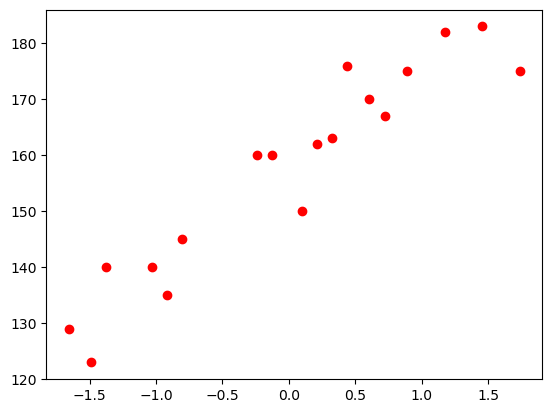

In [23]:
plt.scatter(train_X,train_y,color='red')

Training the Model(Simple Linear Regression)

In [24]:
from sklearn.linear_model import LinearRegression
LinearRegressionModel=LinearRegression()

In [25]:
LinearRegressionModel.fit(train_X,train_y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
LinearRegressionModel.coef_

array([17.03440872])

In [29]:
LinearRegressionModel.intercept_

np.float64(157.5)

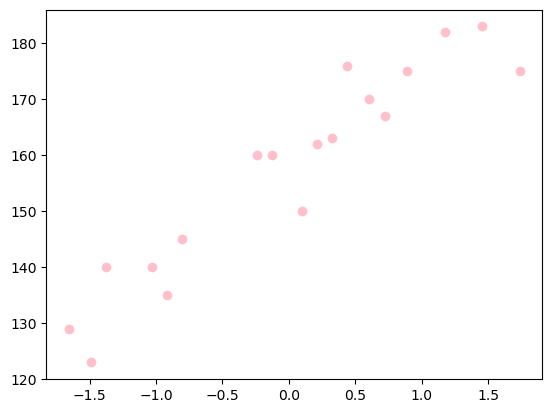

In [31]:
plt.scatter(train_X,train_y,color="pink")

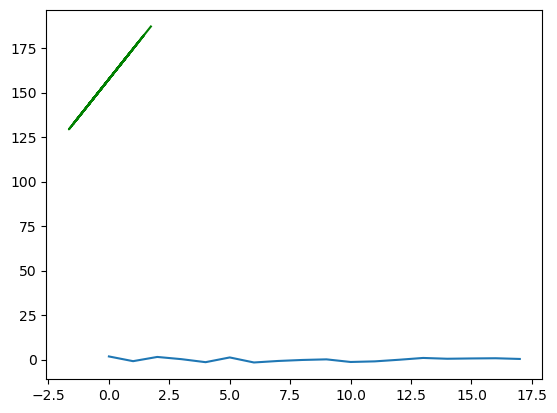

In [34]:
plt.plot(train_X)
plt.plot(train_X,LinearRegressionModel.predict(train_X),'green')

In [37]:
y_pred_test=LinearRegressionModel.predict(test_X)
y_pred_test,test_y

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

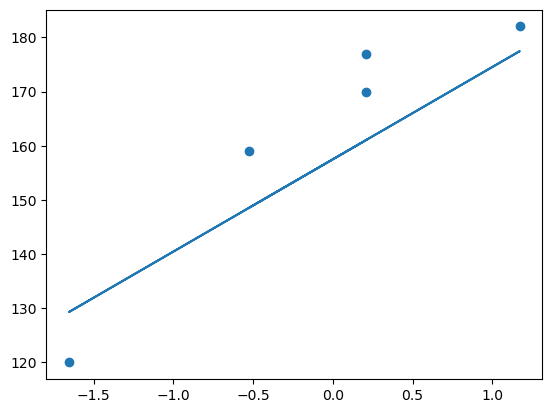

In [39]:
plt.scatter(test_X,test_y)
plt.plot(test_X,LinearRegressionModel.predict(test_X))

Performance Matrix
MSE MAE RMSE R square and adjusted R square

In [40]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [45]:
mse=mean_squared_error(test_y,y_pred_test)
mae=mean_absolute_error(test_y,y_pred_test)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


In [47]:
score=r2_score(test_y,y_pred_test)
print(score)

0.776986986042344


Adjusted R square

In [49]:
n = len(test_y)              # number of samples
p = test_X.shape[1]          # number of features
r2 = score                   # your R² score

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R²:", adj_r2)

Adjusted R²: 0.7026493147231252


In [50]:
LinearRegressionModel

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
##new data point weight is 80
scaled_weight=scaler.transform([[80]])
scaled_weight

array([[0.32350772]])

In [54]:
LinearRegressionModel.predict([scaled_weight[0]])

array([163.01076266])

In [55]:
residuals=test_y-y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

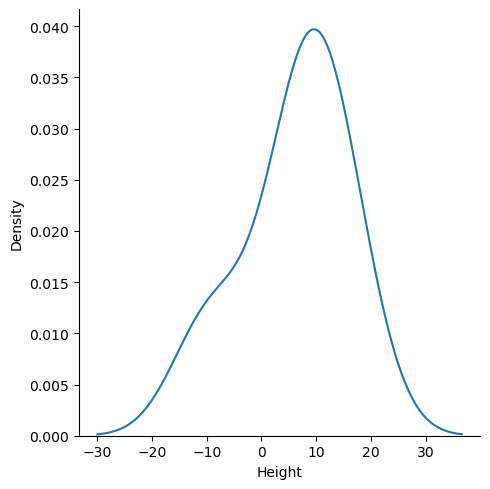

In [56]:
sns.displot(residuals,kind='kde')